# Adaptive Integration

## Grundlagen

- das Integral

  \begin{align*}
  \int_a^b f(x) \: dx
  \end{align*}

  wird mit einer auf Interpolationspolynomen basierenden
  Methode $I(f,a,b)$ (Newton-Cotes, Gauß) approximiert

- um die Qualität der Approximation zu überprüfen, soll
  ein Fehlerindikator hergeleitet werden

- für $I(f,a,b)$ gelten Fehlerabschätzungen der Art

  \begin{align*}
  E = \int_a^b f(x) \: dx - I(f,a,b) = c h^p f^{(q)}(\xi),
  \quad h = b-a,
  \quad \xi \in [a,b]
  \end{align*}

  mit $c$ unabhängig von $f,h$

- um einen Fehlerindikator abzuleiten, spaltet man das Integral in 
  zwei Anteile auf

  \begin{align*} 
  \int_a^b f(x) \: dx 
  = 
   \int_a^\frac{a+b}{2} f(x) \: dx 
  +\int_\frac{a+b}{2}^b f(x) \: dx,
  \end{align*}

  wendet auf beide Teile $I$ an, addiert die Ergebnisse und
  erhält eine neue (in der Regel genauere) Approximation

  \begin{align*} 
  \tilde{I}(f,a,b) = I \Big(f,a,\frac{a+b}{2}\Big) + I(f,\frac{a+b}{2},b).
  \end{align*}

- für den Fehler von $\tilde{I}(f,a,b)$ erhält man

  \begin{align*}
  \tilde{E} 
  &= \int_a^b f(x) \: dx - \tilde{I}(f,a,b)\\
  &=  \int_a            ^\frac{a+b}{2} f(x) \: dx - I\Big(f, a            ,\frac{a+b}{2}\Big)
    + \int_\frac{a+b}{2}^b             f(x) \: dx - I\Big(f, \frac{a+b}{2},b\Big)\\
  &= c \Big(\frac{h}{2}\Big)^p f^{(q)}(\xi_l) + c \Big(\frac{h}{2}\Big)^p f^{(q)}(\xi_r)\\
  & = c h^p \frac{1}{2^{p-1}} \frac{f^{(q)}(\xi_l) + f^{(q)}(\xi_r)}{2}
  \end{align*}

  mit $h=b-a$, $\xi_l \in [a,\frac{a+b}{2}]$, $\xi_r \in [\frac{a+b}{2},b]$

-   nimmt man nun an, dass
    
    \begin{align*}
    f^{(q)}(\xi) \approx f^{(q)}(\xi_l) \approx f^{(q)}(\xi_r)
    \end{align*}
    
    dann gilt
    
    \begin{align*}
    \tilde{E} \approx \frac{1}{2^{p-1}} E
    \end{align*}
    
    bzw.
    
    \begin{align*}
    E \approx 2^{p-1} \tilde{E}
    \end{align*}
    
    also
    
    \begin{align*}
    \tilde{I}(f,a,b) - I(f,a,b) = E - \tilde{E} \approx \big(2^{p-1} - 1\big) \tilde{E}
    \end{align*}
    
    und somit
    
    \begin{align*}
    \tilde{E} \approx \frac{1}{2^{p-1} - 1} \big(\tilde{I}(f,a,b) - I(f,a,b)\big)
    \end{align*}
    
    bzw.
    
    \begin{align*}
    E \approx \frac{2^{p-1}}{2^{p-1} - 1} \big(\tilde{I}(f,a,b) - I(f,a,b)\big)
    \end{align*}
    
-   als Fehlerindikator benutzt man dann
    
    \begin{align*}
    \tilde{F} 
    = \frac{1}{2^{p-1} - 1} \big|\tilde{I}(f,a,b) - I(f,a,b)\big|
    \approx |\tilde{E}|
    \end{align*}
    
    bzw.
    
    \begin{align*}
    F
    = \frac{2^{p-1}}{2^{p-1} - 1} \big|\tilde{I}(f,a,b) - I(f,a,b)\big|
    \approx |E|.
    \end{align*}

-   die einzige Information die wir für den Fehlerindikator benötigen
    ist also die Fehlerordnung $p$ von $I(f,a,b)$ bezüglich $h=b-a$
    
-   um diese zu bestimmen reicht es aus, den Fehler
    
    \begin{align*}
    E(h) = \int_0^h f(x) \: dx - I(f,0,h)
    \end{align*}
    
    nach $h$ in eine Taylorreihe um $h=0$ zu entwickeln

## Adaptive Newton-Cotes Verfahren

In [1]:
import numpy as np
import sympy as sy

import matplotlib.pyplot as plt

from IPython.display import Math, Markdown, Latex


def L(k, n):
    x = sy.symbols('x')
    w = 1
    for i in range(n+1):
        if i != k:
            w *= (x - sy.Rational(i,n)) / (sy.Rational(k,n) - sy.Rational(i,n))
    return sy.Lambda(x, w.simplify())

def beta01(n):
    return [L(k,n)(x).integrate((x,0,1)) for k in range(n+1)]

def nc(f,a,b,n):
    h = (b-a) / sy.Rational(n)
    beta = beta01(n)
    
    w = 0
    for k in range(n+1):
        xk = a + k*h
        w += beta[k] * f(xk)

    return (b-a) * w

def NewtonCotes(f,a,b):
    return nc(f,a,b,n)

def adaptiv(f, a, b, Integrator, p, eps):
    hist = []
    Iabi = []
    def refine(I, a, b):
        m = (a+b)/sy.Rational(2)
        Il = Integrator(f, a, m)
        Ir = Integrator(f, m, b)
        
        It = Il + Ir
        
        Ft = abs(It - I) / sy.Rational(2**(p-1) - 1)
        
        stop = Ft < eps
        #display(Math(r"\tiny [a,b] = [{},{}],\quad I = {},\quad I_l = {},\quad I_r = {},\
        #             \quad \tilde{{I}} = I_l + I_r = {},\
        #             \quad \tilde{{F}} = \Big|\frac{{\tilde{{I}}-I}}{{3}}\Big| = {}\
        #             \approx {}, \quad Stop = {}".format(*map(sy.latex,[a,b,I,Il,Ir,It,Ft,Ft.evalf(2), stop]))))

        if stop:
            stopstr = rf"< {eps}"
        else:
            stopstr = rf"\geq {eps}"
        #hist.append(r"[{a},{b}] & {Il} & {Ir} & {It} & {Ft} & {Ft.evalf(2)} & {stopstr}")
        hist.append(r"[{},{}] & {} & {} & {} & {} & {} & {} & ".format(*map(sy.latex,[a, b, I, Il, Ir, It, Ft, Ft.evalf(2)])) + stopstr)

        #hist.append([a, b, I, Il, Ir, It, Ft, Ft.evalf(2), stop])
        
        if stop:
            Iabi.append(((a, m), Il))
            Iabi.append(((m, b), Ir))
            return It
        else:
            return refine(Il, a, m) + refine(Ir, m, b)
    
    return (refine(Integrator(f, a, b), a, b), Iabi, hist)


- für Newton-Cotes Formeln kann man die Fehlerordnung leicht berechnen

- wir betrachten hier Polynomgrad 

In [2]:
# Polynomgrad Newton-Cotes, 1 = Trapez, 2 = Simpson, ...
n = 1

Math(f"n = {n}")

<IPython.core.display.Math object>

- der führende Term in der Fehlerentwicklung ist

In [3]:
# fuehrender Term der Fehlerentwicklung
x,h = sy.symbols('x,h')
f = sy.Function('f')

Integralf   = sy.Lambda(h, f(x).integrate((x,0,h)))
NewtonCotes0h = sy.Lambda(h, nc(f,0,h,n))

E = sy.Lambda(h, Integralf(h) - NewtonCotes0h(h))


def taylorLeading(f,x,x0=0):
    p = 0
    i = 0
    while p==0:
        dfix0 = sy.Derivative(f(x),x,i).doit().subs(x,x0) 
        p += sy.simplify((x-x0)**i/sy.factorial(i) * dfix0).doit()
        i +=1
    
    return p.doit()

Erest = taylorLeading(E,h,0)

Erest

-h**3*Subs(Derivative(f(h), (h, 2)), h, 0)/12

- somit ist

In [4]:
p = sy.degree(Erest)

Math(f"p={p}")

<IPython.core.display.Math object>

- für den Fehlerindikator $\tilde{F}$ gilt also

In [5]:
Math(rf"\tilde{{F}} ={sy.latex(1/(2**(p-1)-1))}  |\tilde{{I}} - I|")

<IPython.core.display.Math object>

- wir benutzen den Fehlerindikator jetzt zur adaptiven Integralapproximation von

In [6]:
a = 1
b = 5
x = sy.symbols('x')
f = sy.Lambda(x, 1/x)

Iexakt = sy.Integral(f(x),(x,a,b))

Math(rf"{sy.latex(Iexakt)} = {sy.latex(Iexakt.doit())} \approx {sy.latex(Iexakt.doit().evalf(5))}")

<IPython.core.display.Math object>

- als Abbruchkriterium für die Adaption verwenden wir 

In [7]:
eps = 0.02

Math(rf"\tilde{{F}} <  {eps}")

<IPython.core.display.Math object>

- das Verfahren führt folgende Schritte durch:

In [8]:
# Auswertung
erg, Iabi, hist = adaptiv(f, a, b, NewtonCotes, p, eps)

Iabitex = "+".join([sy.latex(w[1]) for w in Iabi])

# Iterationshistorie
histtex = r"\\ \\ ".join(hist)


Latex(
rf"""
\begin{{align*}}
  \begin{{matrix}}
  [a,b] & I & I_l & I_r & \tilde{{I}} = I_l + I_r & \tilde{{F}} & \tilde{{F}} \approx &  \\ \\
  {histtex}
  \end{{matrix}}
  \end{{align*}}
"""
)

<IPython.core.display.Latex object>

- damit erhalten wir als Ergebnis

In [9]:
Math(rf"""
  {sy.latex(Iexakt)} 
  \approx 
  {Iabitex}
  =
  {sy.latex(erg)} \approx {sy.latex(erg.evalf(5))}
""")

<IPython.core.display.Math object>

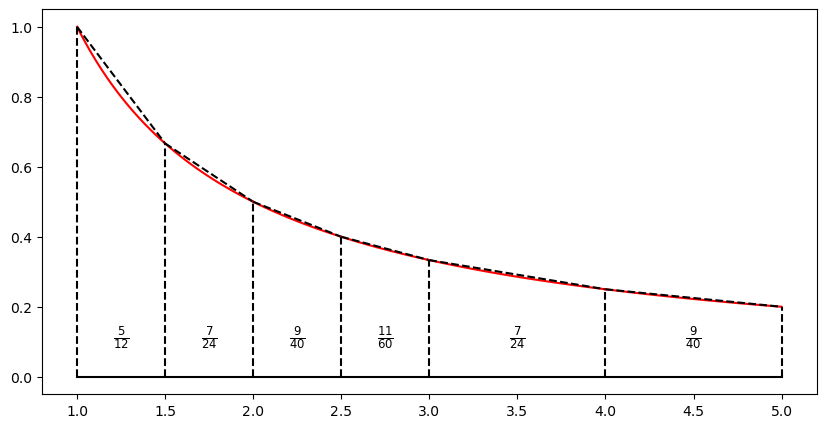

In [10]:
# Bild
ff = sy.lambdify(x, f(x), 'numpy')

plt.figure(figsize=(10,5))
for ((ai,bi), Ii) in Iabi:
    ai, bi = list(map(float, (ai,bi)))
    xx = np.linspace(ai, bi)
    plt.plot(xx, ff(xx), 'r')
    
    plt.plot([ai, bi], [f(ai), f(bi)], 'k--')
    plt.plot( [ai,ai], [0,ff(ai)], 'k--')
    plt.text(0.5*(ai+bi), 0.1, '${}$'.format(sy.latex(Ii)), horizontalalignment='center', fontsize=12)
plt.plot( [bi,bi], [0,ff(bi)], 'k--')
plt.plot( [a,b], [0,0], 'k');